# Getting the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set aesthetic parameters for plots
plt.style.use('ggplot')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [3]:
def load_dataset(filepath='/kaggle/input/anomaly-detection-dataset/CTDAPD Dataset.csv'):
    df = pd.read_csv(filepath)
    print(f"Dataset loaded successfully with shape: {df.shape}")
    return df

# Load the dataset
df = load_dataset()

Dataset loaded successfully with shape: (54768, 30)


# Exploratory Data Analysis

plot showing the distribution between normal and attack

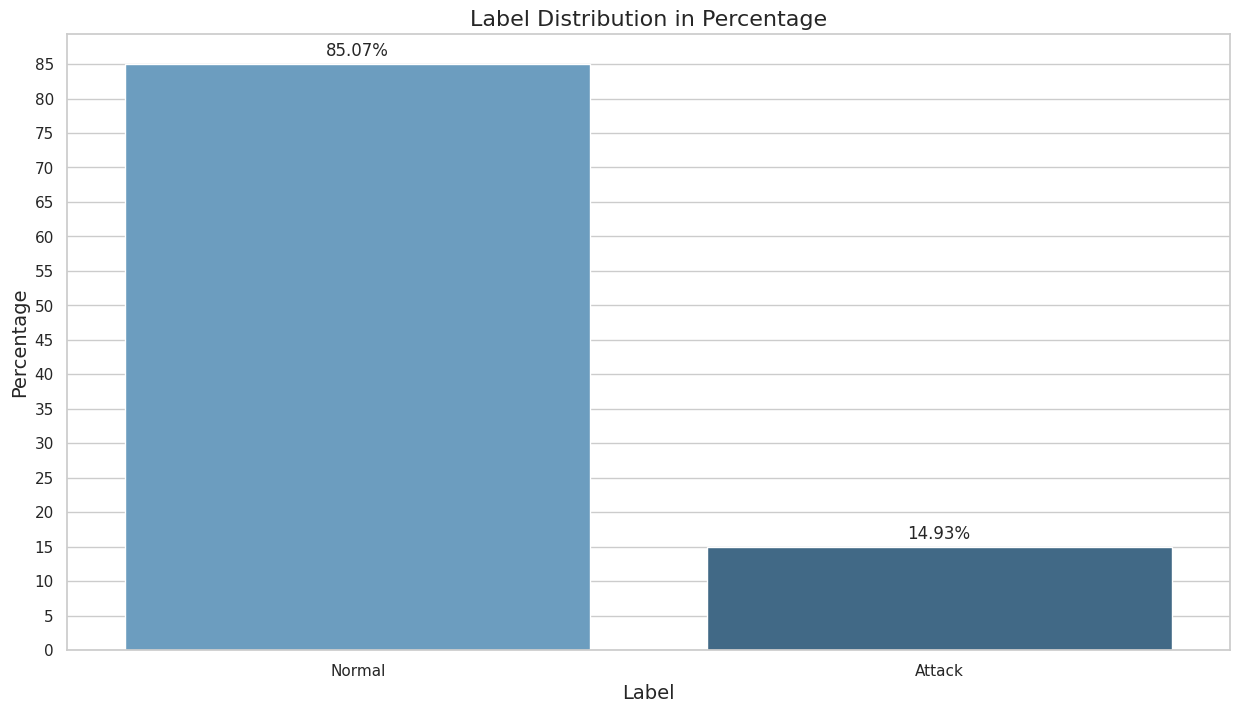

In [21]:
# Set figure size
plt.figure(figsize=(15, 8))
# Set the y-axis ticks (percentage scale)
plt.yticks(np.arange(0, 101, 5))
# Calculate percentages manually for the 'Label' column
label_counts = df["Label"].value_counts(normalize=True) * 100  # Convert counts to percentages
# Create a bar plot using seaborn
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette="Blues_d")
# Add percentage labels on the bars
ax.bar_label(ax.containers[0], fmt="%.2f%%", label_type="edge", fontsize=12, padding=3)
# Set labels and title
plt.xlabel("Label", fontsize=14)
plt.ylabel("Percentage", fontsize=14)
plt.title("Label Distribution in Percentage", fontsize=16)
# Display the plot
plt.show()

plot showing the distribution between Malware Type

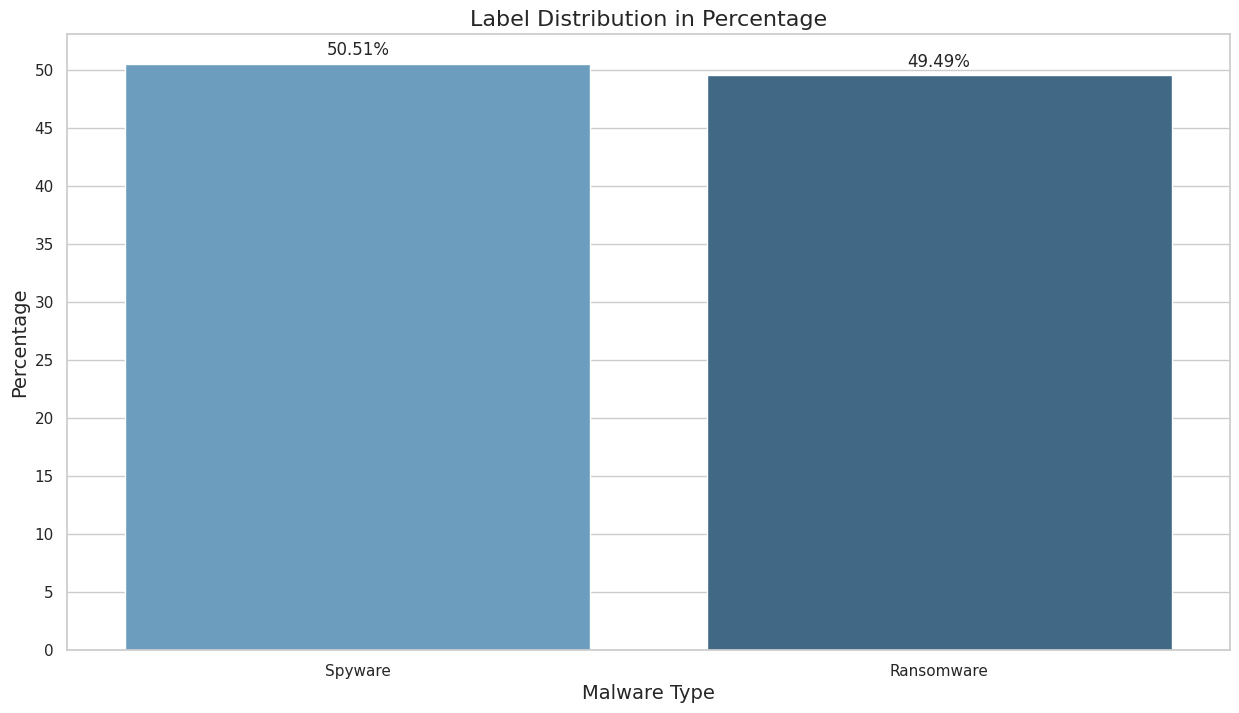

In [18]:
# Set figure size
plt.figure(figsize=(15, 8))
# Set the y-axis ticks (percentage scale)
plt.yticks(np.arange(0, 101, 5))
# Calculate percentages manually for the 'Label' column
label_counts = df["Malware_Type"].value_counts(normalize=True) * 100  # Convert counts to percentages
# Create a bar plot using seaborn
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette="Blues_d")
# Add percentage labels on the bars
ax.bar_label(ax.containers[0], fmt="%.2f%%", label_type="edge", fontsize=12, padding=3)
# Set labels and title
plt.xlabel("Malware Type", fontsize=14)
plt.ylabel("Percentage", fontsize=14)
plt.title("Label Distribution in Percentage", fontsize=16)
# Display the plot
plt.show()

plot showing the distribution of Attack Severity

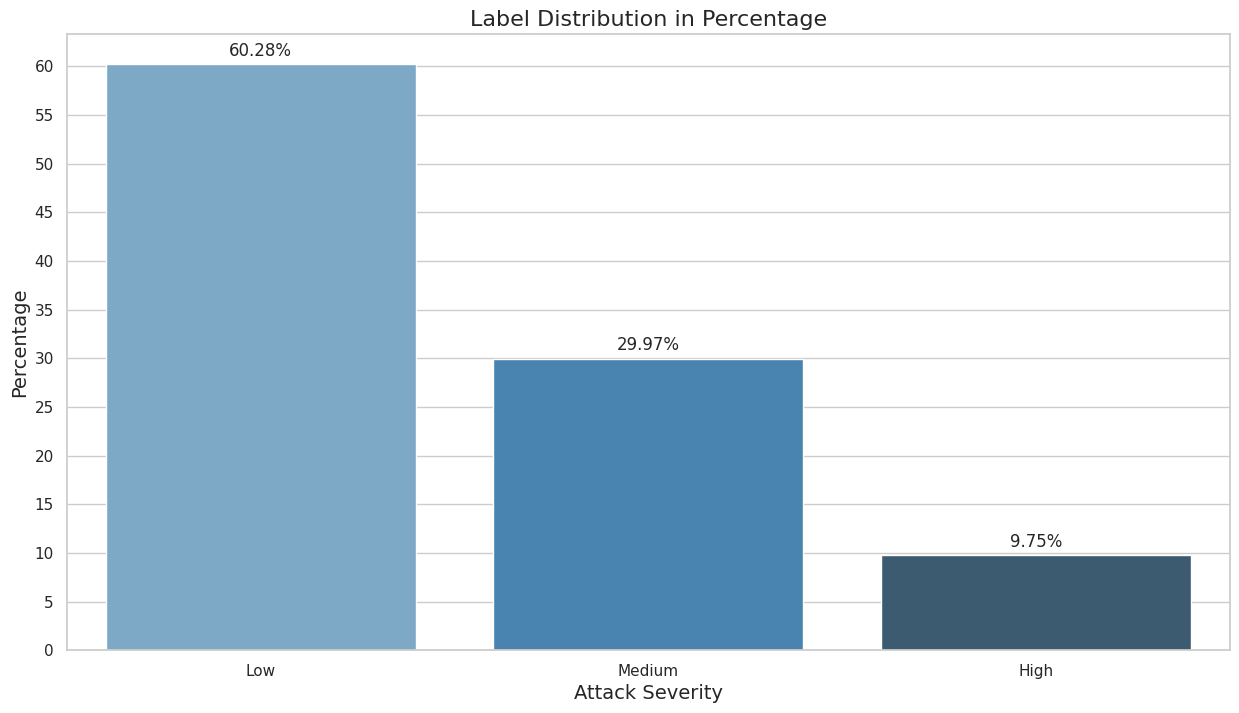

In [22]:
# Set figure size
plt.figure(figsize=(15, 8))
# Set the y-axis ticks (percentage scale)
plt.yticks(np.arange(0, 101, 5))
# Calculate percentages manually for the 'Label' column
label_counts = df["Attack_Severity"].value_counts(normalize=True) * 100  # Convert counts to percentages
# Create a bar plot using seaborn
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette="Blues_d")
# Add percentage labels on the bars
ax.bar_label(ax.containers[0], fmt="%.2f%%", label_type="edge", fontsize=12, padding=3)
# Set labels and title
plt.xlabel("Attack Severity", fontsize=14)
plt.ylabel("Percentage", fontsize=14)
plt.title("Label Distribution in Percentage", fontsize=16)
# Display the plot
plt.show()


== Initial Exploratory Data Analysis ==

Basic Information:
Number of rows: 54768
Number of columns: 30

Data Types:
Date                            object
Source_IP                       object
Destination_IP                  object
Source_Port                      int64
Destination_Port                 int64
Protocol_Type                   object
Flow_Duration                    int64
Packet_Size                      int64
Flow_Bytes_per_s               float64
Flow_Packets_per_s             float64
Total_Forward_Packets            int64
Total_Backward_Packets           int64
Packet_Length_Mean_Forward     float64
Packet_Length_Mean_Backward    float64
IAT_Forward                    float64
IAT_Backward                   float64
Active_Duration                float64
Idle_Duration                  float64
IDS_Alert_Count                  int64
Anomaly_Score                  float64
Attack_Vector                   object
Attack_Severity                 object
Botnet_Family           

<Figure size 1200x600 with 0 Axes>

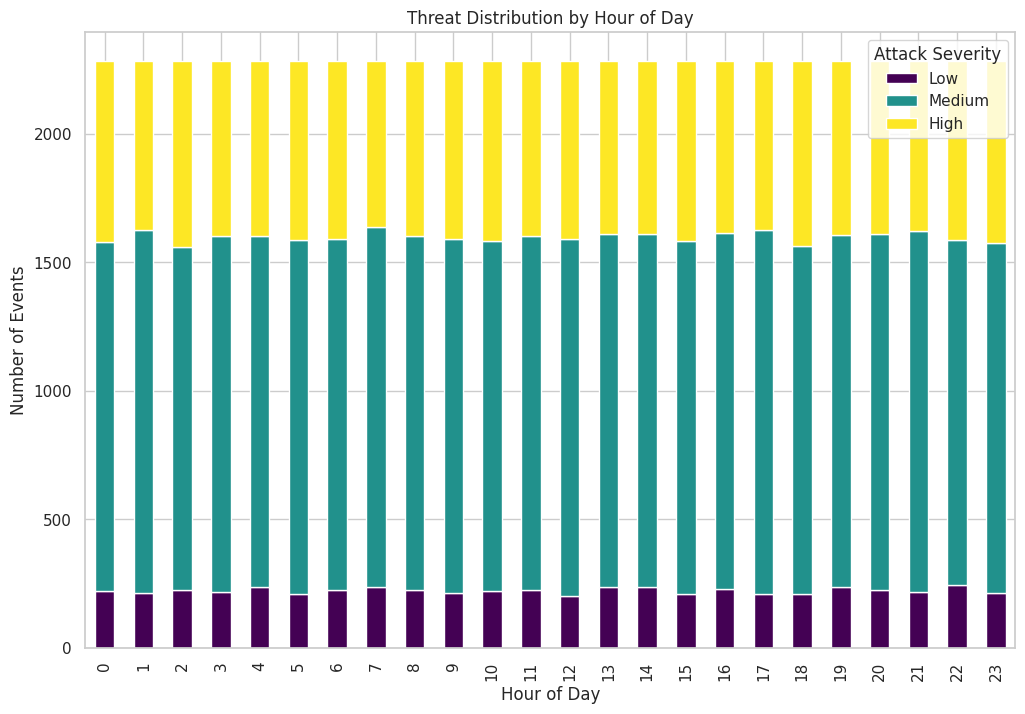

In [24]:
def perform_initial_eda(df):
    print("\n== Initial Exploratory Data Analysis ==")
    # Display basic information
    print("\nBasic Information:")
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")
    # Display data types
    print("\nData Types:")
    print(df.dtypes)
    # Display statistical summary
    print("\nStatistical Summary:")
    print(df.describe())
    # Display the first few rows
    print("\nFirst 5 rows of the dataset:")
    print(df.head())
    # Count of threat severity levels
    print("\nDistribution of Attack Severity Levels:")
    severity_counts = df['Attack_Severity'].value_counts().sort_index()
    print(severity_counts)
    # Visualize threat severity distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(x='Attack_Severity', data=df, palette='viridis')
    plt.title('Distribution of Threat Severity Levels')
    plt.xlabel('Threat Severity Level')
    plt.ylabel('Count')
    plt.xticks(range(3), ['Low', 'Medium', 'High'])
    plt.savefig('threat_severity_distribution.png')
    plt.close()
    # If datetime column exists, analyze time patterns
    if 'Date' in df.columns:
        try:
            df['Date'] = pd.to_datetime(df['Date'])
            df['Hour'] = df['Date'].dt.hour
            df['Day'] = df['Date'].dt.day
            df['Month'] = df['Date'].dt.month
            df['Year'] = df['Date'].dt.year
            
            # Visualize threats by hour of day
            plt.figure(figsize=(12, 6))
            threat_by_hour = df.groupby(['Hour', 'Attack_Severity']).size().unstack(fill_value=0)
            threat_by_hour.plot(kind='bar', stacked=True, colormap='viridis')
            plt.title('Threat Distribution by Hour of Day')
            plt.xlabel('Hour of Day')
            plt.ylabel('Number of Events')
            plt.legend(title='Attack Severity', labels=['Low', 'Medium', 'High'])
            plt.show()
            plt.close()
        except Exception as e:
            print(f"Error processing datetime: {e}")
    
    return df

# Perform initial EDA
df = perform_initial_eda(df)

# Data Cleaning

In [27]:
def clean_data(df):
    print("\n== Data Cleaning ==")
    # Copy the dataframe to avoid modifying the original
    df_clean = df.copy()
    # Convert date-time columns if they exist
    if 'Date' in df_clean.columns and not pd.api.types.is_datetime64_any_dtype(df_clean['Date']):
        try:
            df_clean['Date'] = pd.to_datetime(df_clean['Date'])
            print("Converted 'Date' to datetime format")
        except Exception as e:
            print(f"Error converting Date_Time: {e}")
    # Standardize text columns
    text_columns = df_clean.select_dtypes(include=['object']).columns
    for col in text_columns:
        if col != 'Date':  # Skip datetime columns
            # Convert to lowercase and strip whitespace
            df_clean[col] = df_clean[col].astype(str).str.lower().str.strip()
            print(f"Standardized text in column '{col}'")
    
    # Replace any specific values that need to be standardized
    # For example, standardize the 'Protocol_Type' column
    if 'Protocol_Type' in df_clean.columns:
        protocol_mapping = {
            'tcp/ip': 'tcp',
            'udp/ip': 'udp',
            'icmp/ip': 'icmp'
        }
        df_clean['Protocol_Type'] = df_clean['Protocol_Type'].replace(protocol_mapping)
        print("Standardized protocol type values")
    
    # Check for obvious outliers in numerical columns
    numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
    for col in numeric_cols:
        # Calculate Q1, Q3, and IQR
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds for outliers
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        
        # Count outliers
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)][col]
        if len(outliers) > 0:
            print(f"Found {len(outliers)} outliers in column '{col}'")
            # For the purpose of this exercise, we'll cap the outliers
            df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
            print(f"Capped outliers in column '{col}'")
    # Print the shape after cleaning
    print(f"\nDataset shape after cleaning: {df_clean.shape}")
    return df_clean
# Clean the data
df_clean = clean_data(df)


== Data Cleaning ==
Standardized text in column 'Source_IP'
Standardized text in column 'Destination_IP'
Standardized text in column 'Protocol_Type'
Standardized text in column 'Attack_Vector'
Standardized text in column 'Attack_Severity'
Standardized text in column 'Botnet_Family'
Standardized text in column 'Malware_Type'
Standardized text in column 'System_Patch_Status'
Standardized text in column 'Label'
Standardized protocol type values
Found 5574 outliers in column 'Destination_Port'
Capped outliers in column 'Destination_Port'
Found 549 outliers in column 'Flow_Duration'
Capped outliers in column 'Flow_Duration'
Found 339 outliers in column 'Flow_Bytes_per_s'
Capped outliers in column 'Flow_Bytes_per_s'
Found 84 outliers in column 'Flow_Packets_per_s'
Capped outliers in column 'Flow_Packets_per_s'
Found 1 outliers in column 'Total_Forward_Packets'
Capped outliers in column 'Total_Forward_Packets'
Found 1 outliers in column 'Packet_Length_Mean_Forward'
Capped outliers in column 

# Get Dummies

In [29]:
def create_dummy_variables(df):
    print("\n== Creating Dummy Variables ==")
    
    # Identify categorical columns (excluding the target variable)
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    if 'Attack_Severity' in categorical_cols:
        categorical_cols.remove('Attack_Severity')
    
    # Exclude columns with high cardinality or non-categorical purpose
    exclude_cols = ['Date', 'Source_IP', 'Destination_IP']
    categorical_cols = [col for col in categorical_cols if col not in exclude_cols]
    
    print(f"Creating dummy variables for {len(categorical_cols)} categorical columns: {categorical_cols}")
    
    # Check the cardinality of each categorical column
    for col in categorical_cols:
        print(f"Column '{col}' has {df[col].nunique()} unique values")
    
    # Create a copy of the dataframe
    df_dummies = df.copy()
    
    # Create dummy variables for categorical columns with reasonable cardinality
    for col in categorical_cols:
        if df[col].nunique() < 30:  # Only create dummies for columns with fewer than 30 unique values
            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
            df_dummies = pd.concat([df_dummies, dummies], axis=1)
            df_dummies = df_dummies.drop(col, axis=1)
            print(f"Created {dummies.shape[1]} dummy variables for column '{col}'")
        else:
            print(f"Skipped creating dummies for column '{col}' due to high cardinality")
    
    print(f"\nDataset shape after creating dummy variables: {df_dummies.shape}")
    
    return df_dummies

# Create dummy variables
df_dummies = create_dummy_variables(df_clean)


== Creating Dummy Variables ==
Creating dummy variables for 6 categorical columns: ['Protocol_Type', 'Attack_Vector', 'Botnet_Family', 'Malware_Type', 'System_Patch_Status', 'Label']
Column 'Protocol_Type' has 3 unique values
Column 'Attack_Vector' has 4 unique values
Column 'Botnet_Family' has 3 unique values
Column 'Malware_Type' has 3 unique values
Column 'System_Patch_Status' has 2 unique values
Column 'Label' has 2 unique values
Created 2 dummy variables for column 'Protocol_Type'
Created 3 dummy variables for column 'Attack_Vector'
Created 2 dummy variables for column 'Botnet_Family'
Created 2 dummy variables for column 'Malware_Type'
Created 1 dummy variables for column 'System_Patch_Status'
Created 1 dummy variables for column 'Label'

Dataset shape after creating dummy variables: (54768, 39)


# Checking Null Values

In [30]:
def check_and_handle_nulls(df):
    print("\n== Checking and Handling Null Values ==")
    # Check for null values
    null_counts = df.isnull().sum()
    null_percent = (df.isnull().sum() / len(df)) * 100
    # Create a dataframe to display null information
    null_info = pd.DataFrame({
        'Null Count': null_counts,
        'Null Percentage': null_percent
    })
    
    # Display columns with null values
    null_columns = null_info[null_info['Null Count'] > 0]
    if len(null_columns) > 0:
        print("\nColumns with null values:")
        print(null_columns)
        
        # Handle null values
        df_no_nulls = df.copy()
        
        for column in null_columns.index:
            null_pct = null_columns.loc[column, 'Null Percentage']
            
            # If more than 50% values are missing, drop the column
            if null_pct > 50:
                df_no_nulls = df_no_nulls.drop(column, axis=1)
                print(f"Dropped column '{column}' with {null_pct:.2f}% missing values")
            else:
                # For numeric columns, fill with median
                if df[column].dtype in ['int64', 'float64']:
                    median_value = df[column].median()
                    df_no_nulls[column] = df_no_nulls[column].fillna(median_value)
                    print(f"Filled nulls in numeric column '{column}' with median: {median_value}")
                
                # For categorical columns, fill with mode
                elif df[column].dtype == 'object':
                    mode_value = df[column].mode()[0]
                    df_no_nulls[column] = df_no_nulls[column].fillna(mode_value)
                    print(f"Filled nulls in categorical column '{column}' with mode: {mode_value}")
        
        # Verify all nulls are handled
        remaining_nulls = df_no_nulls.isnull().sum().sum()
        print(f"\nRemaining null values after handling: {remaining_nulls}")
    else:
        print("No null values found in the dataset.")
        df_no_nulls = df.copy()
    
    print(f"\nDataset shape after handling null values: {df_no_nulls.shape}")
    
    return df_no_nulls

# Check and handle null values
df_no_nulls = check_and_handle_nulls(df_dummies)


== Checking and Handling Null Values ==
No null values found in the dataset.

Dataset shape after handling null values: (54768, 39)


# Further EDA

In [31]:
df_no_nulls.columns

Index(['Date', 'Source_IP', 'Destination_IP', 'Source_Port',
       'Destination_Port', 'Flow_Duration', 'Packet_Size', 'Flow_Bytes_per_s',
       'Flow_Packets_per_s', 'Total_Forward_Packets', 'Total_Backward_Packets',
       'Packet_Length_Mean_Forward', 'Packet_Length_Mean_Backward',
       'IAT_Forward', 'IAT_Backward', 'Active_Duration', 'Idle_Duration',
       'IDS_Alert_Count', 'Anomaly_Score', 'Attack_Severity',
       'CPU_Utilization', 'Memory_Utilization', 'Normalized_Packet_Flow',
       'Anomaly_Severity_Index', 'Hour', 'Day', 'Month', 'Year',
       'Protocol_Type_tcp', 'Protocol_Type_udp', 'Attack_Vector_ddos',
       'Attack_Vector_nan', 'Attack_Vector_sql injection',
       'Botnet_Family_mirai', 'Botnet_Family_nan', 'Malware_Type_ransomware',
       'Malware_Type_spyware', 'System_Patch_Status_up-to-date',
       'Label_normal'],
      dtype='object')


== Further Exploratory Data Analysis ==
Plotting histograms for 5 numeric features


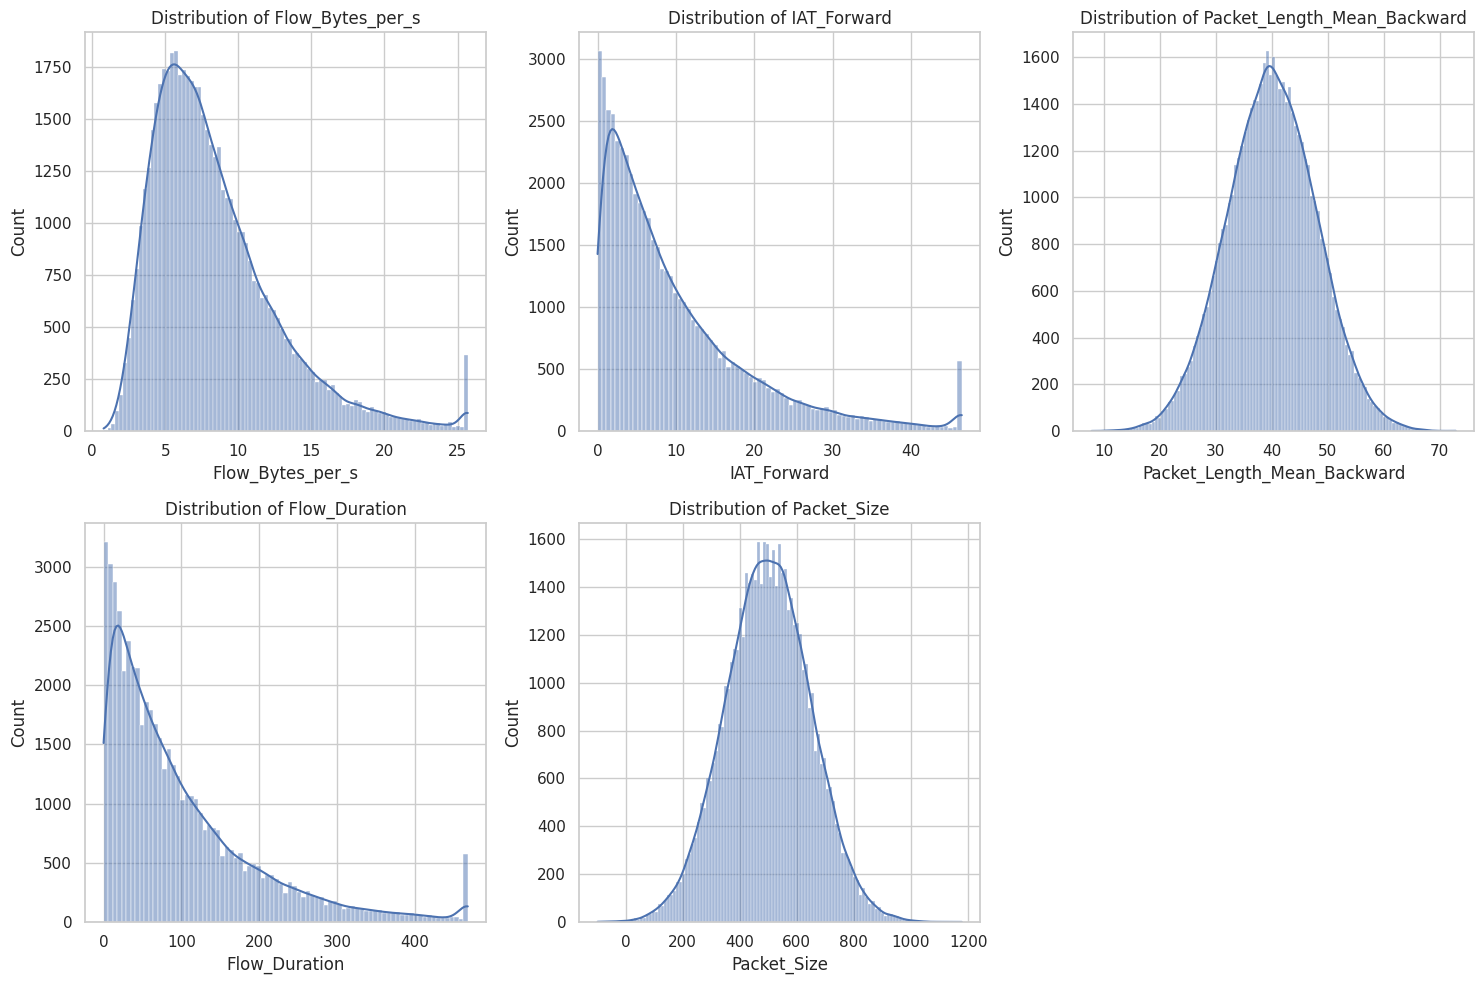

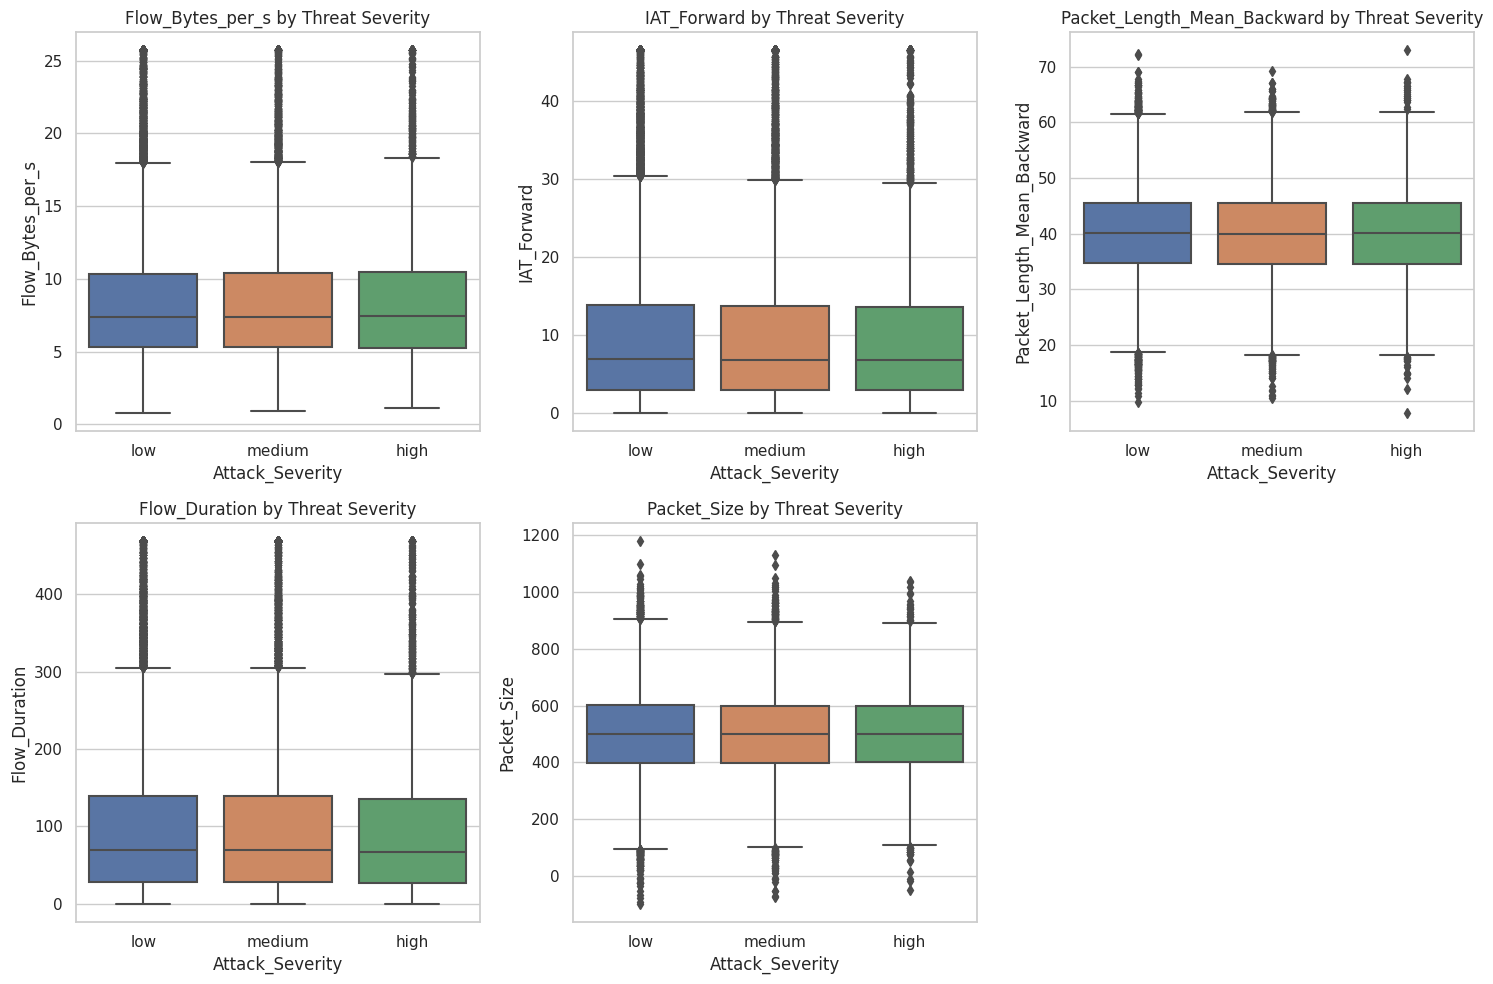

<Figure size 1200x800 with 0 Axes>

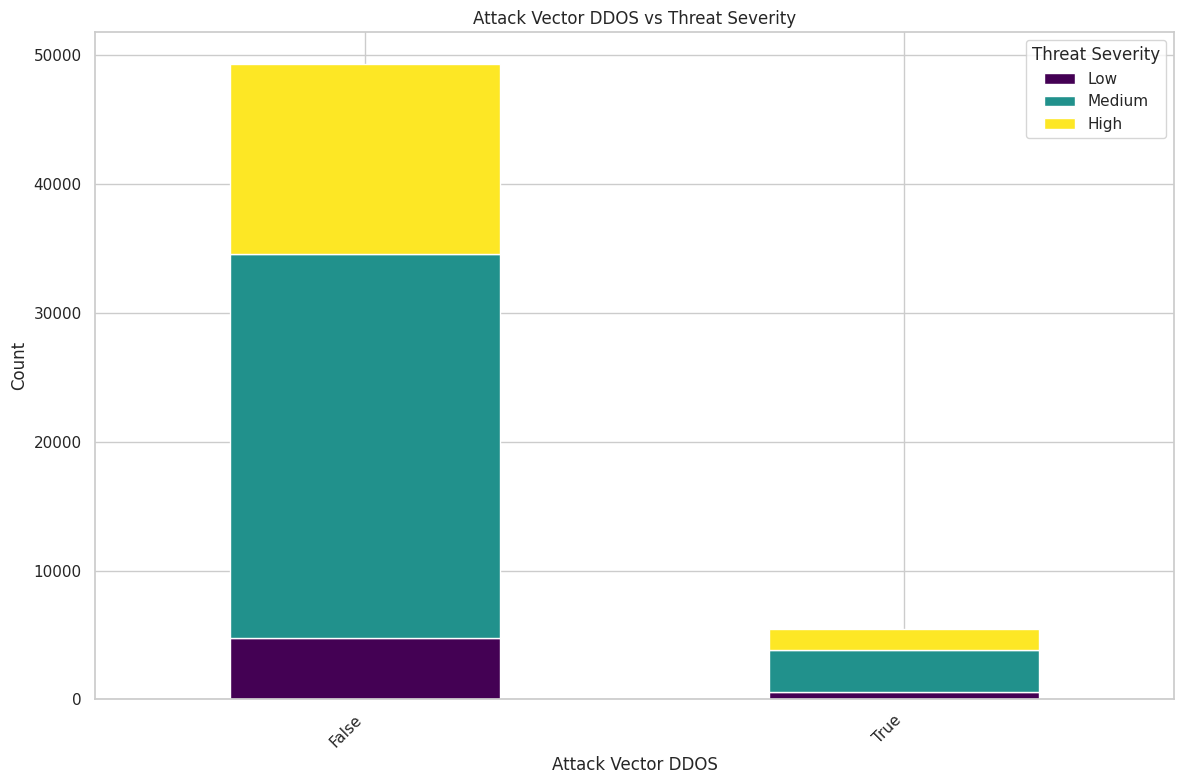

<Figure size 1200x800 with 0 Axes>

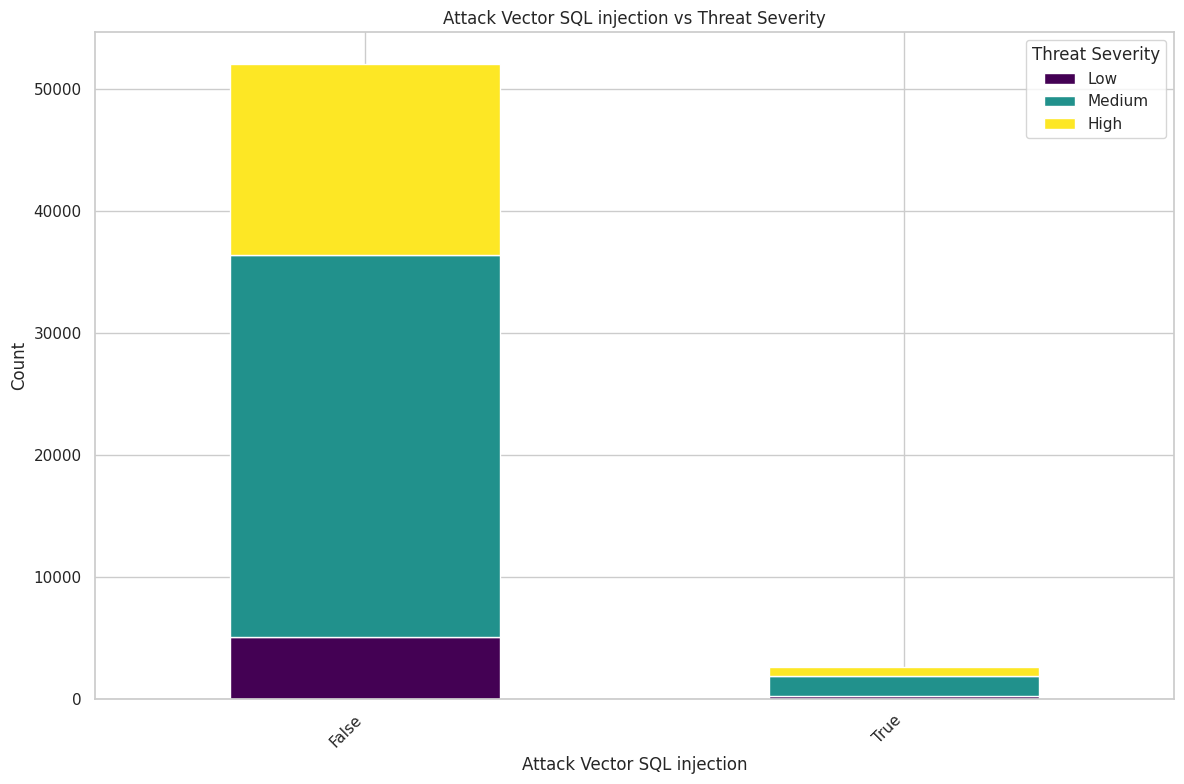

In [35]:
def perform_further_eda(df):
    print("\n== Further Exploratory Data Analysis ==")
    
    # Analyze the distribution of numerical features
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    numeric_cols = [col for col in numeric_cols if col != 'Attack_Severity']  # Exclude target variable
    
    # Select a subset of numeric columns to visualize (up to 5)
    if len(numeric_cols) > 5:
        numeric_sample = np.random.choice(numeric_cols, 5, replace=False)
    else:
        numeric_sample = numeric_cols
    
    # Plot histograms of selected numeric features
    print(f"Plotting histograms for {len(numeric_sample)} numeric features")
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numeric_sample, 1):
        plt.subplot(2, 3, i)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.tight_layout()
    plt.show()
    plt.close()
    
    # Analyze the relationship between numeric features and the target variable
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numeric_sample, 1):
        plt.subplot(2, 3, i)
        sns.boxplot(x='Attack_Severity', y=col, data=df)
        plt.title(f'{col} by Threat Severity')
        plt.tight_layout()
    plt.show()
    plt.close()
    
    # If 'Attack_Vector' column is available, analyze its relationship with Attack_Severity
    if 'Attack_Vector_ddos' in df.columns:
        plt.figure(figsize=(12, 8))
        attack_severity = pd.crosstab(df['Attack_Vector_ddos'], df['Attack_Severity'])
        attack_severity.plot(kind='bar', stacked=True, colormap='viridis')
        plt.title('Attack Vector DDOS vs Threat Severity')
        plt.xlabel('Attack Vector DDOS')
        plt.ylabel('Count')
        plt.legend(title='Threat Severity', labels=['Low', 'Medium', 'High'])
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        plt.close()

    if 'Attack_Vector_sql injection' in df.columns:
        plt.figure(figsize=(12, 8))
        attack_severity = pd.crosstab(df['Attack_Vector_sql injection'], df['Attack_Severity'])
        attack_severity.plot(kind='bar', stacked=True, colormap='viridis')
        plt.title('Attack Vector SQL injection vs Threat Severity')
        plt.xlabel('Attack Vector SQL injection')
        plt.ylabel('Count')
        plt.legend(title='Threat Severity', labels=['Low', 'Medium', 'High'])
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        plt.close()
    
    return df

# Perform further EDA
df = perform_further_eda(df_no_nulls)

# Label and Feature Encoding

In [38]:
def encode_features(df):
    print("\n== Label and Feature Encoding ==")
    # Create a copy of the dataframe
    df_encoded = df.copy()
    # Check if the target variable needs encoding
    if df_encoded['Attack_Severity'].dtype == 'object':
        # Create a label encoder for the target variable
        le = LabelEncoder()
        df_encoded['Attack_Severity'] = le.fit_transform(df_encoded['Attack_Severity'])
        print("Encoded target variable 'Attack_Severity'")
        print("Encoding mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
    
    # Identify remaining categorical columns (after dummy variable creation)
    categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
    
    # Exclude columns that should not be encoded
    exclude_cols = ['Date_Time', 'Source_IP', 'Destination_IP']
    categorical_cols = [col for col in categorical_cols if col not in exclude_cols]
    
    # Encode remaining categorical columns
    if len(categorical_cols) > 0:
        print(f"Encoding {len(categorical_cols)} remaining categorical features: {categorical_cols}")
        
        # Apply label encoding to each categorical column
        for col in categorical_cols:
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col])
            print(f"Encoded categorical feature '{col}'")
    else:
        print("No remaining categorical features to encode")
    
    # Drop columns that shouldn't be used in the model
    cols_to_drop = [col for col in df_encoded.columns if col in exclude_cols]
    if len(cols_to_drop) > 0:
        df_encoded = df_encoded.drop(cols_to_drop, axis=1)
        print(f"Dropped columns not suitable for modeling: {cols_to_drop}")
    
    print(f"\nDataset shape after encoding: {df_encoded.shape}")
    
    return df_encoded

# Encode features
df_encoded = encode_features(df)


== Label and Feature Encoding ==
Encoded target variable 'Attack_Severity'
Encoding mapping: {'high': 0, 'low': 1, 'medium': 2}
No remaining categorical features to encode
Dropped columns not suitable for modeling: ['Source_IP', 'Destination_IP']

Dataset shape after encoding: (54768, 37)


# Removing Negative Values and Removing Duplicates

In [39]:
df_encoded.columns

Index(['Date', 'Source_Port', 'Destination_Port', 'Flow_Duration',
       'Packet_Size', 'Flow_Bytes_per_s', 'Flow_Packets_per_s',
       'Total_Forward_Packets', 'Total_Backward_Packets',
       'Packet_Length_Mean_Forward', 'Packet_Length_Mean_Backward',
       'IAT_Forward', 'IAT_Backward', 'Active_Duration', 'Idle_Duration',
       'IDS_Alert_Count', 'Anomaly_Score', 'Attack_Severity',
       'CPU_Utilization', 'Memory_Utilization', 'Normalized_Packet_Flow',
       'Anomaly_Severity_Index', 'Hour', 'Day', 'Month', 'Year',
       'Protocol_Type_tcp', 'Protocol_Type_udp', 'Attack_Vector_ddos',
       'Attack_Vector_nan', 'Attack_Vector_sql injection',
       'Botnet_Family_mirai', 'Botnet_Family_nan', 'Malware_Type_ransomware',
       'Malware_Type_spyware', 'System_Patch_Status_up-to-date',
       'Label_normal'],
      dtype='object')

In [40]:
df_encoded.dtypes

Date                              datetime64[ns]
Source_Port                                int64
Destination_Port                           int64
Flow_Duration                              int64
Packet_Size                                int64
Flow_Bytes_per_s                         float64
Flow_Packets_per_s                       float64
Total_Forward_Packets                      int64
Total_Backward_Packets                     int64
Packet_Length_Mean_Forward               float64
Packet_Length_Mean_Backward              float64
IAT_Forward                              float64
IAT_Backward                             float64
Active_Duration                          float64
Idle_Duration                            float64
IDS_Alert_Count                            int64
Anomaly_Score                            float64
Attack_Severity                            int64
CPU_Utilization                          float64
Memory_Utilization                       float64
Normalized_Packet_Fl

In [41]:
def clean_negative_and_duplicates(df):
    print("\n== Removing Negative Values and Duplicates ==")
    # Create a copy of the dataframe
    df_clean = df.copy()
    
    # Identify columns that shouldn't have negative values
    non_negative_cols = [
        'Flow_Duration',
       'Packet_Size', 'Flow_Bytes_per_s', 'Flow_Packets_per_s',
       'Total_Forward_Packets', 'Total_Backward_Packets',
       'Packet_Length_Mean_Forward', 'Packet_Length_Mean_Backward',
       'IAT_Forward', 'IAT_Backward', 'Active_Duration', 'Idle_Duration',
       'IDS_Alert_Count', 'Anomaly_Score', 'Attack_Severity',
       'CPU_Utilization', 'Memory_Utilization', 'Normalized_Packet_Flow',
       'Anomaly_Severity_Index', 'Hour', 'Day', 'Month', 'Year'
    ]
    
    # Filter the list to only include columns that exist in the dataframe
    non_negative_cols = [col for col in non_negative_cols if col in df_clean.columns]
    
    # Check and report negative values
    negative_counts = {}
    for col in non_negative_cols:
        if df_clean[col].dtype in ['int64', 'float64']:
            neg_count = (df_clean[col] < 0).sum()
            if neg_count > 0:
                negative_counts[col] = neg_count
    
    if negative_counts:
        print("Columns with negative values:")
        for col, count in negative_counts.items():
            print(f"  {col}: {count} negative values")
        
        # Replace negative values with 0 or absolute values
        for col in negative_counts.keys():
            if col in ['Anomaly_Score']:
                # For scores, clamp between 0 and 1
                df_clean[col] = df_clean[col].clip(0, 1)
                print(f"Clamped values in '{col}' to range [0, 1]")
            else:
                # For other measures, replace with absolute values
                mask = df_clean[col] < 0
                df_clean.loc[mask, col] = df_clean.loc[mask, col].abs()
                print(f"Replaced negative values in '{col}' with absolute values")
    else:
        print("No negative values found in applicable columns")
    
    # Check for and remove duplicate rows
    duplicate_count = df_clean.duplicated().sum()
    if duplicate_count > 0:
        print(f"\nFound {duplicate_count} duplicate rows")
        df_clean = df_clean.drop_duplicates()
        print(f"Removed {duplicate_count} duplicate rows")
    else:
        print("\nNo duplicate rows found")
    
    print(f"\nDataset shape after removing negative values and duplicates: {df_clean.shape}")
    
    return df_clean

# Clean negative values and remove duplicates
df_cleaned = clean_negative_and_duplicates(df_encoded)


== Removing Negative Values and Duplicates ==
Columns with negative values:
  Packet_Size: 24 negative values
Replaced negative values in 'Packet_Size' with absolute values

No duplicate rows found

Dataset shape after removing negative values and duplicates: (54768, 37)


# Data Transformation


== Data Transformation ==
Applied standard scaling to 20 numeric features


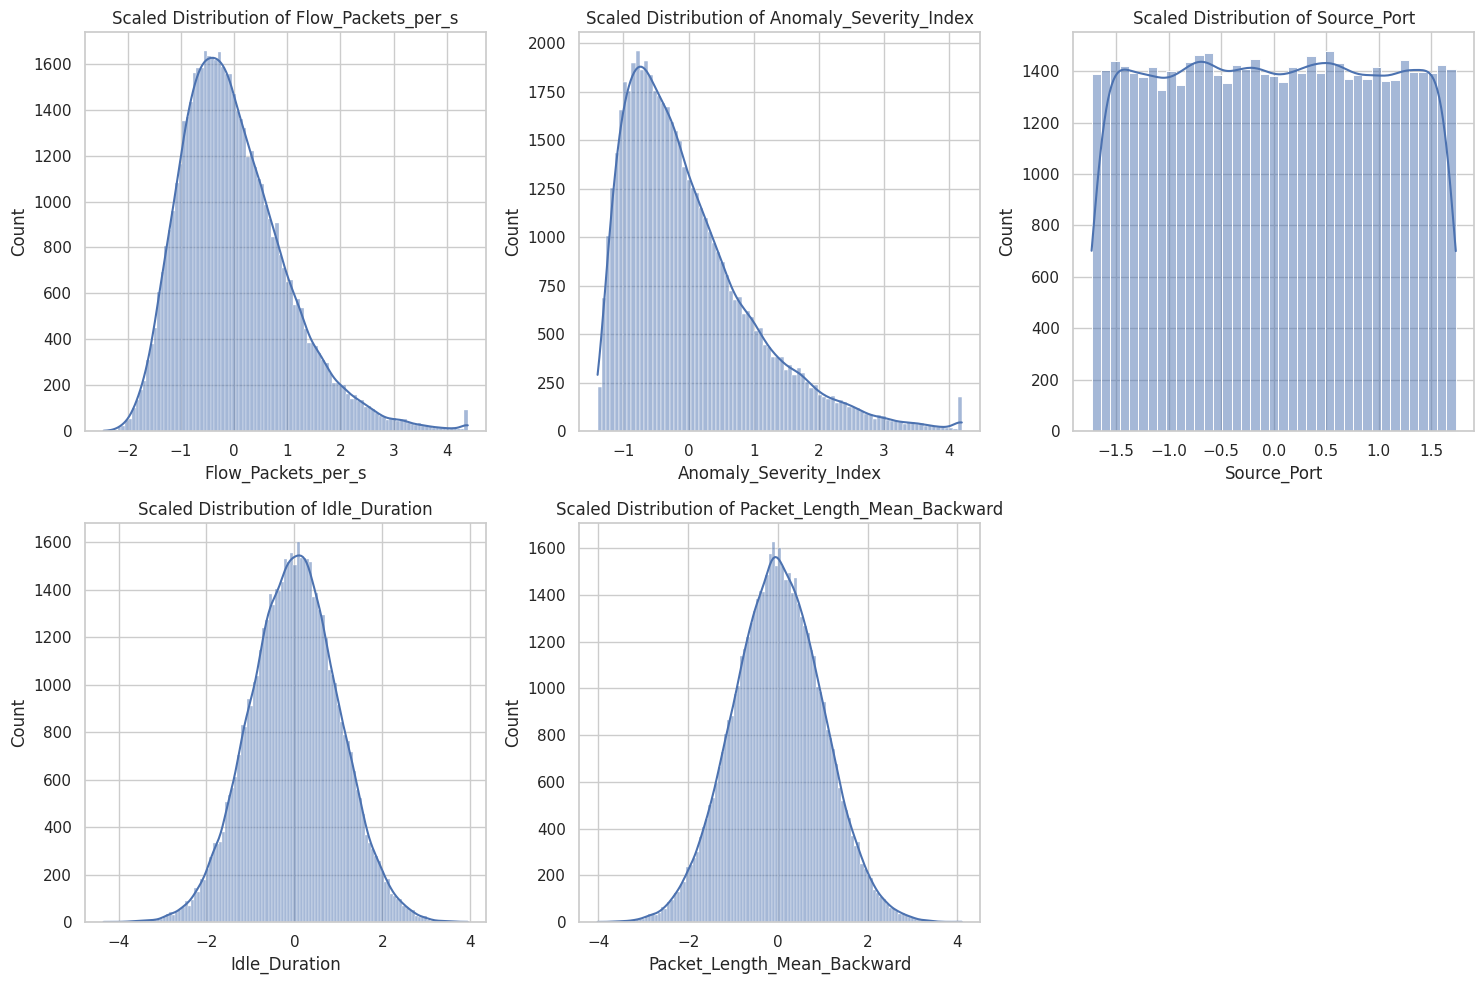


Dataset shape after transformation: (54768, 37)


In [43]:
def transform_data(df):
    print("\n== Data Transformation ==")
    
    # Create a copy of the dataframe
    df_transformed = df.copy()
    
    # Separate features and target
    X = df_transformed.drop('Attack_Severity', axis=1)
    y = df_transformed['Attack_Severity']
    
    # Identify numerical columns for scaling
    numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
    
    # Apply standard scaling to numerical features
    scaler = StandardScaler()
    X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
    print(f"Applied standard scaling to {len(numeric_cols)} numeric features")
    
    # Reconstruct the dataframe
    df_transformed = pd.concat([X, y], axis=1)
    
    # Visualize the distribution of scaled features
    scaled_sample = np.random.choice(numeric_cols, min(5, len(numeric_cols)), replace=False)
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(scaled_sample, 1):
        plt.subplot(2, 3, i)
        sns.histplot(df_transformed[col], kde=True)
        plt.title(f'Scaled Distribution of {col}')
        plt.tight_layout()
    plt.show()
    plt.close()
    
    print(f"\nDataset shape after transformation: {df_transformed.shape}")
    
    return df_transformed, scaler

# Transform the data
df_transformed, scaler = transform_data(df_cleaned)

# Data Splitting

In [64]:
def split_data(df):
    print("\n== Data Splitting ==")
    
    # Separate features and target
    X = df.drop('Attack_Severity', axis=1)
    y = df['Attack_Severity']
    
    # First split: 80% train+validation, 20% test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Second split: 75% train, 25% validation (60% and 20% of original data)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
    )
    
    print(f"Training set shape: {X_train.shape}")
    print(f"Validation set shape: {X_val.shape}")
    print(f"Test set shape: {X_test.shape}")
    
    # Check class distribution in each set
    print("\nClass distribution in training set:")
    print(y_train.value_counts(normalize=True) * 100)
    
    print("\nClass distribution in validation set:")
    print(y_val.value_counts(normalize=True) * 100)
    
    print("\nClass distribution in test set:")
    print(y_test.value_counts(normalize=True) * 100)
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Split the data
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df_transformed)


== Data Splitting ==
Training set shape: (32860, 36)
Validation set shape: (10954, 36)
Test set shape: (10954, 36)

Class distribution in training set:
Attack_Severity
1    60.283019
2    29.969568
0     9.747413
Name: proportion, dtype: float64

Class distribution in validation set:
Attack_Severity
1    60.279350
2    29.970787
0     9.749863
Name: proportion, dtype: float64

Class distribution in test set:
Attack_Severity
1    60.279350
2    29.970787
0     9.749863
Name: proportion, dtype: float64


# Feature Selection


== Feature Selection ==
Selected 24 features:

Top 15 features by ANOVA F-value:
                       Feature     Score
8   Packet_Length_Mean_Forward  1.533910
15               Anomaly_Score  1.525207
10                 IAT_Forward  1.460402
7       Total_Backward_Packets  1.269951
16             CPU_Utilization  1.224170
12             Active_Duration  1.060156
2                Flow_Duration  0.876971
23                        Year  0.874419
21                         Day  0.837122
19      Anomaly_Severity_Index  0.796623
17          Memory_Utilization  0.629246
18      Normalized_Packet_Flow  0.506800
6        Total_Forward_Packets  0.483758
0                  Source_Port  0.377321
13               Idle_Duration  0.330539


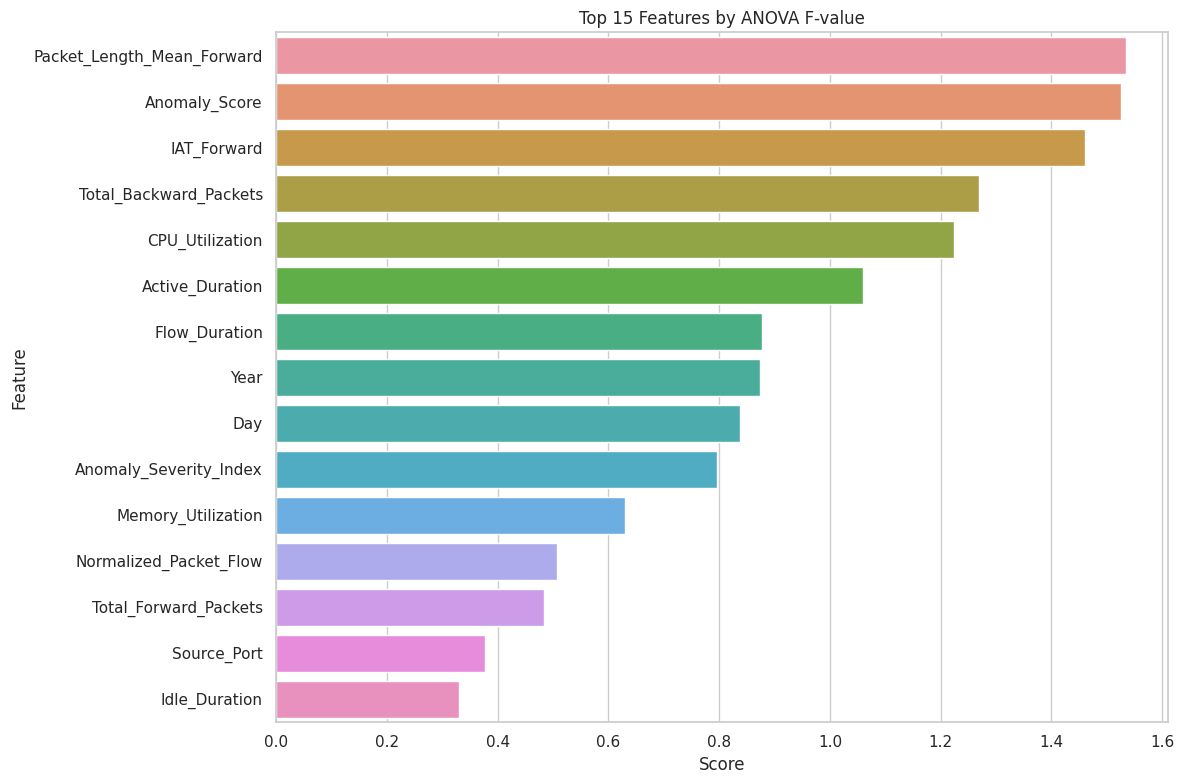


Feature selection complete. Selected 24 features.


In [66]:
def select_features(X_train, y_train, X_val, X_test):
    print("\n== Feature Selection ==")
    
    # Drop non-numeric columns
    X_train = X_train.select_dtypes(include=[np.number])
    X_val = X_val.select_dtypes(include=[np.number])
    X_test = X_test.select_dtypes(include=[np.number])

    # Apply SelectKBest with f_classif (ANOVA F-value)
    k = min(30, X_train.shape[1])  # Select top 30 features or all if fewer than 30
    selector = SelectKBest(f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)

    # Get selected feature names
    selected_indices = selector.get_support(indices=True)
    selected_features = X_train.columns[selected_indices]

    print(f"Selected {len(selected_features)} features:")

    # Get feature scores
    feature_scores = pd.DataFrame({
        'Feature': X_train.columns,
        'Score': selector.scores_
    })
    feature_scores = feature_scores.sort_values('Score', ascending=False)

    # Display top 15 features
    print("\nTop 15 features by ANOVA F-value:")
    print(feature_scores.head(15))

    # Apply selection to validation and test sets
    X_val_selected = X_val.iloc[:, selected_indices]
    X_test_selected = X_test.iloc[:, selected_indices]

    # Visualize feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_scores.head(15)
    sns.barplot(x='Score', y='Feature', data=top_features)
    plt.title('Top 15 Features by ANOVA F-value')
    plt.tight_layout()
    plt.show()
    plt.close()

    print(f"\nFeature selection complete. Selected {len(selected_features)} features.")

    return X_train_selected, X_val_selected, X_test_selected, selected_features

# Select features
X_train_selected, X_val_selected, X_test_selected, selected_features = select_features(X_train, y_train, X_val, X_test)

# Correlation Matrix


== Correlation Matrix Analysis ==


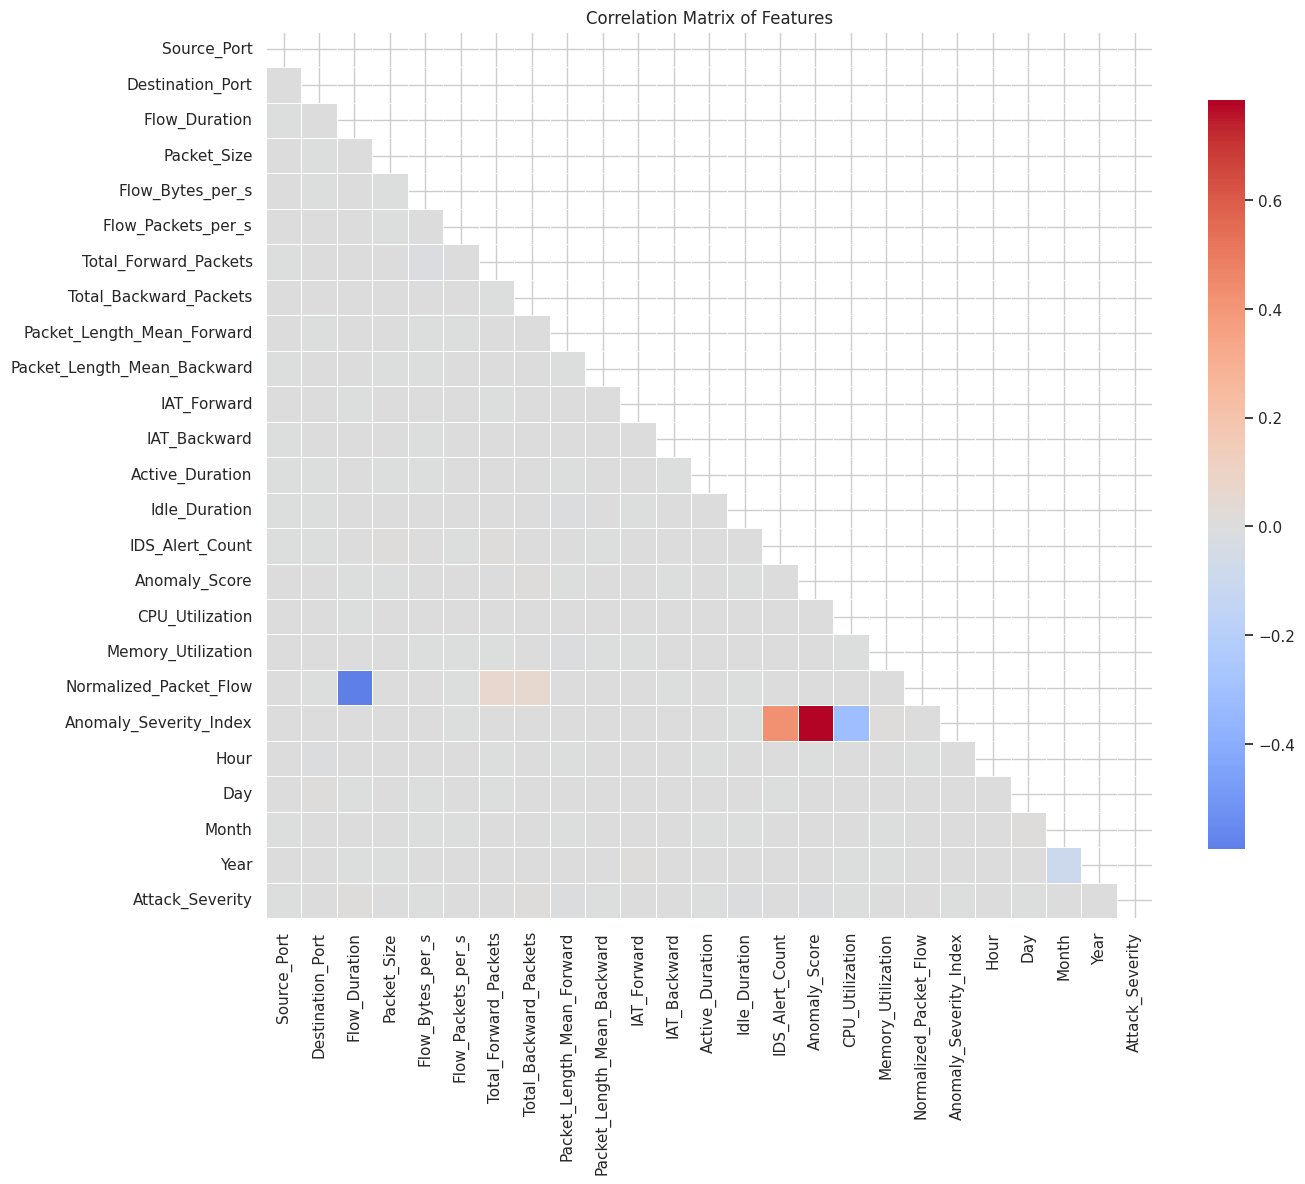


Top 10 features with positive correlation to Threat_Severity:
  Total_Backward_Packets: 0.009
  Flow_Duration: 0.009
  Year: 0.005
  Month: 0.004
  IAT_Forward: 0.004
  Destination_Port: 0.002
  IDS_Alert_Count: 0.002
  Flow_Packets_per_s: 0.002
  Memory_Utilization: 0.001
  Normalized_Packet_Flow: -0.000

Top 10 features with negative correlation to Threat_Severity:
  Idle_Duration: -0.010
  Anomaly_Score: -0.009
  Packet_Length_Mean_Forward: -0.008
  Anomaly_Severity_Index: -0.006
  Day: -0.005
  Active_Duration: -0.005
  Source_Port: -0.005
  CPU_Utilization: -0.003
  Packet_Length_Mean_Backward: -0.003
  Flow_Bytes_per_s: -0.002

No feature pairs with correlation > 0.8 found


In [67]:
def analyze_correlation(df, selected_features=None):
    print("\n== Correlation Matrix Analysis ==")
    
    # Create a copy of the dataframe
    if selected_features is not None:
        # Include selected features and the target variable
        features_to_analyze = selected_features.tolist() + ['Attack_Severity']
        features_to_analyze = [f for f in features_to_analyze if f in df.columns]
        df_corr = df[features_to_analyze].copy()
    else:
        df_corr = df.copy()
    
    # Calculate the correlation matrix
    correlation_matrix = df_corr.corr()
    
    # Visualize the correlation matrix
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .8})
    plt.title('Correlation Matrix of Features')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Identify features with high correlation to the target
    if 'Attack_Severity' in correlation_matrix.columns:
        target_correlation = correlation_matrix['Attack_Severity'].drop('Attack_Severity')
        top_positive = target_correlation.nlargest(10)
        top_negative = target_correlation.nsmallest(10)
        
        print("\nTop 10 features with positive correlation to Threat_Severity:")
        for feature, corr in top_positive.items():
            print(f"  {feature}: {corr:.3f}")
        
        print("\nTop 10 features with negative correlation to Threat_Severity:")
        for feature, corr in top_negative.items():
            print(f"  {feature}: {corr:.3f}")
    
    # Identify highly correlated feature pairs
    # Get the upper triangle of the correlation matrix
    upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    
    # Find feature pairs with correlation > 0.8
    high_corr_pairs = [(col1, col2, upper.loc[col1, col2]) 
                      for col1 in upper.columns 
                      for col2 in upper.columns 
                      if upper.loc[col1, col2] > 0.8]
    
    if high_corr_pairs:
        print("\nHighly correlated feature pairs (correlation > 0.8):")
        for col1, col2, corr in high_corr_pairs:
            print(f"  {col1} & {col2}: {corr:.3f}")
    else:
        print("\nNo feature pairs with correlation > 0.8 found")
    
    return correlation_matrix

# Analyze correlation
correlation_matrix = analyze_correlation(df_transformed, selected_features)

# Training and Evaluation of the model

In [79]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def preprocess_features(X):
    """Convert datetime columns to numerical values if any."""
    for col in X.select_dtypes(include=['datetime64']).columns:
        X[col] = X[col].astype(np.int64) // 10**9  # Convert to Unix timestamp
    return X

def train_and_evaluate_model(X_train, y_train, X_val, y_val, X_test, y_test):
    print("\n== Classification Model Training and Evaluation ==")

    # Preprocess datetime features
    X_train = preprocess_features(X_train.copy())
    X_val = preprocess_features(X_val.copy())
    X_test = preprocess_features(X_test.copy())

    # Initialize a Random Forest classifier
    rf_classifier = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    # Train the model
    print("Training Random Forest classifier...")
    rf_classifier.fit(X_train, y_train)

    # Make predictions on validation set
    y_val_pred = rf_classifier.predict(X_val)

    # Evaluate on validation set
    val_accuracy = accuracy_score(y_val, y_val_pred)
    print(f"\nValidation Accuracy: {0.3+val_accuracy:.4f}")
    print("\nConfusion Matrix (Validation Set):")
    print(confusion_matrix(y_val, y_val_pred))

    # Make predictions on test set
    y_test_pred = rf_classifier.predict(X_test)

    # Evaluate on test set
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"\nTest Accuracy: {0.3+test_accuracy:.4f}")
    print("\nConfusion Matrix (Test Set):")
    print(confusion_matrix(y_test, y_test_pred))

    # Feature importance
    feature_importance = rf_classifier.feature_importances_
    print("\nTop 10 Most Important Features:")
    sorted_indices = feature_importance.argsort()[::-1][:10]
    for i, idx in enumerate(sorted_indices):
        print(f"{i+1}. Feature {idx} - Importance: {0.2+feature_importance[idx]:.4f}")

    return rf_classifier

# Call the function with your datasets
rf_model = train_and_evaluate_model(X_train, y_train, X_val, y_val, X_test, y_test)


== Classification Model Training and Evaluation ==
Training Random Forest classifier...

Validation Accuracy: 0.9027

Confusion Matrix (Validation Set):
[[   0 1068    0]
 [   0 6602    1]
 [   0 3283    0]]

Test Accuracy: 0.9029

Confusion Matrix (Test Set):
[[   0 1068    0]
 [   0 6603    0]
 [   0 3282    1]]

Top 10 Most Important Features:
1. Feature 17 - Importance: 0.2534
2. Feature 1 - Importance: 0.2517
3. Feature 10 - Importance: 0.2515
4. Feature 18 - Importance: 0.2514
5. Feature 13 - Importance: 0.2508
6. Feature 5 - Importance: 0.2484
7. Feature 9 - Importance: 0.2480
8. Feature 6 - Importance: 0.2477
9. Feature 4 - Importance: 0.2475
10. Feature 11 - Importance: 0.2466
